In [1]:
%load_ext autoreload
%autoreload 2

import sys
import urllib.parse  
from pathlib import Path
import numpy as np
from astropy.io import fits

project_root = Path("/home/maju/projeto/LS5039")
sys.path.append(str(project_root / "src"))

from periodograma import (
    calcular_lomb_scargle_hz, 
    calcular_periodograma_medio_gti
)

# Parâmetros
ano = "2017"
binagem = "b10s" 
energia = "10_30kev"

arq_entrada = project_root / "data" / "processed" / f"sub_{ano}_{binagem}_{energia}.lc"

if not arq_entrada.exists():
    raise FileNotFoundError(f"Ficheiro não encontrado: {arq_entrada}")

with fits.open(arq_entrada) as hdul:
    data = hdul[1].data
    time = np.asarray(data['TIME'], dtype=float)
    rate = np.asarray(data['RATE'], dtype=float)
    err = np.asarray(data['ERROR'], dtype=float) if 'ERROR' in data.names else None

print(f"Ficheiro carregado com sucesso: {arq_entrada.name}")
print(f"Número de pontos: {len(time)}")

Ficheiro carregado com sucesso: sub_2017_b10s_10_30kev.lc
Número de pontos: 177351


In [ ]:
min_p_seg = 2.0      # Período mínimo em segundos (2s -> 0.5 Hz)
max_p_seg = 1800.0   # Período máximo em segundos (30 minutos)

freq_hz, power_med, best_freq_hz, best_p_seg, n_gtis = calcular_periodograma_medio_gti(
    time, rate, err, 
    limite_gap_seg=30,  
    min_p_seg=2.0, 
    max_p_seg=1800.0
)

print(f"Janelas Orbitais (GTIs) analisadas: {n_gtis}")
print(f"Melhor Frequência Rápida: {best_freq_hz:.5f} Hz")
print(f"Melhor Período Correspondente: {best_p_seg:.2f} segundos")

Periodograma médio calculado sobre 6 janelas orbitais contínuas (GTIs).
Janelas Orbitais (GTIs) analisadas: 6
Melhor Frequência Rápida: 0.34461 Hz
Melhor Período Correspondente: 2.90 segundos


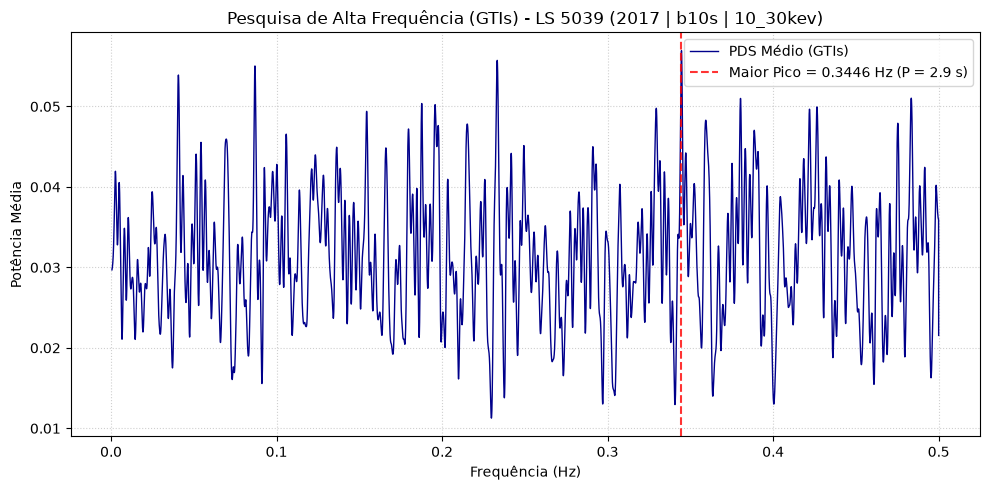

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot do Periodograma Médio
plt.plot(freq_hz, power_med, color='darkblue', lw=1.0, label='PDS Médio (GTIs)')

# Marcador do pico de maior potência
plt.axvline(best_freq_hz, color='red', ls='--', alpha=0.8, 
            label=f'Maior Pico = {best_freq_hz:.4f} Hz (P = {best_p_seg:.1f} s)')

plt.xlabel('Frequência (Hz)')
plt.ylabel('Potência Média')
plt.title(f'Pesquisa de Alta Frequência (GTIs) - LS 5039 ({ano} | {binagem} | {energia})')
plt.grid(True, ls=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Total de GTIs extraídos para plotagem: 85


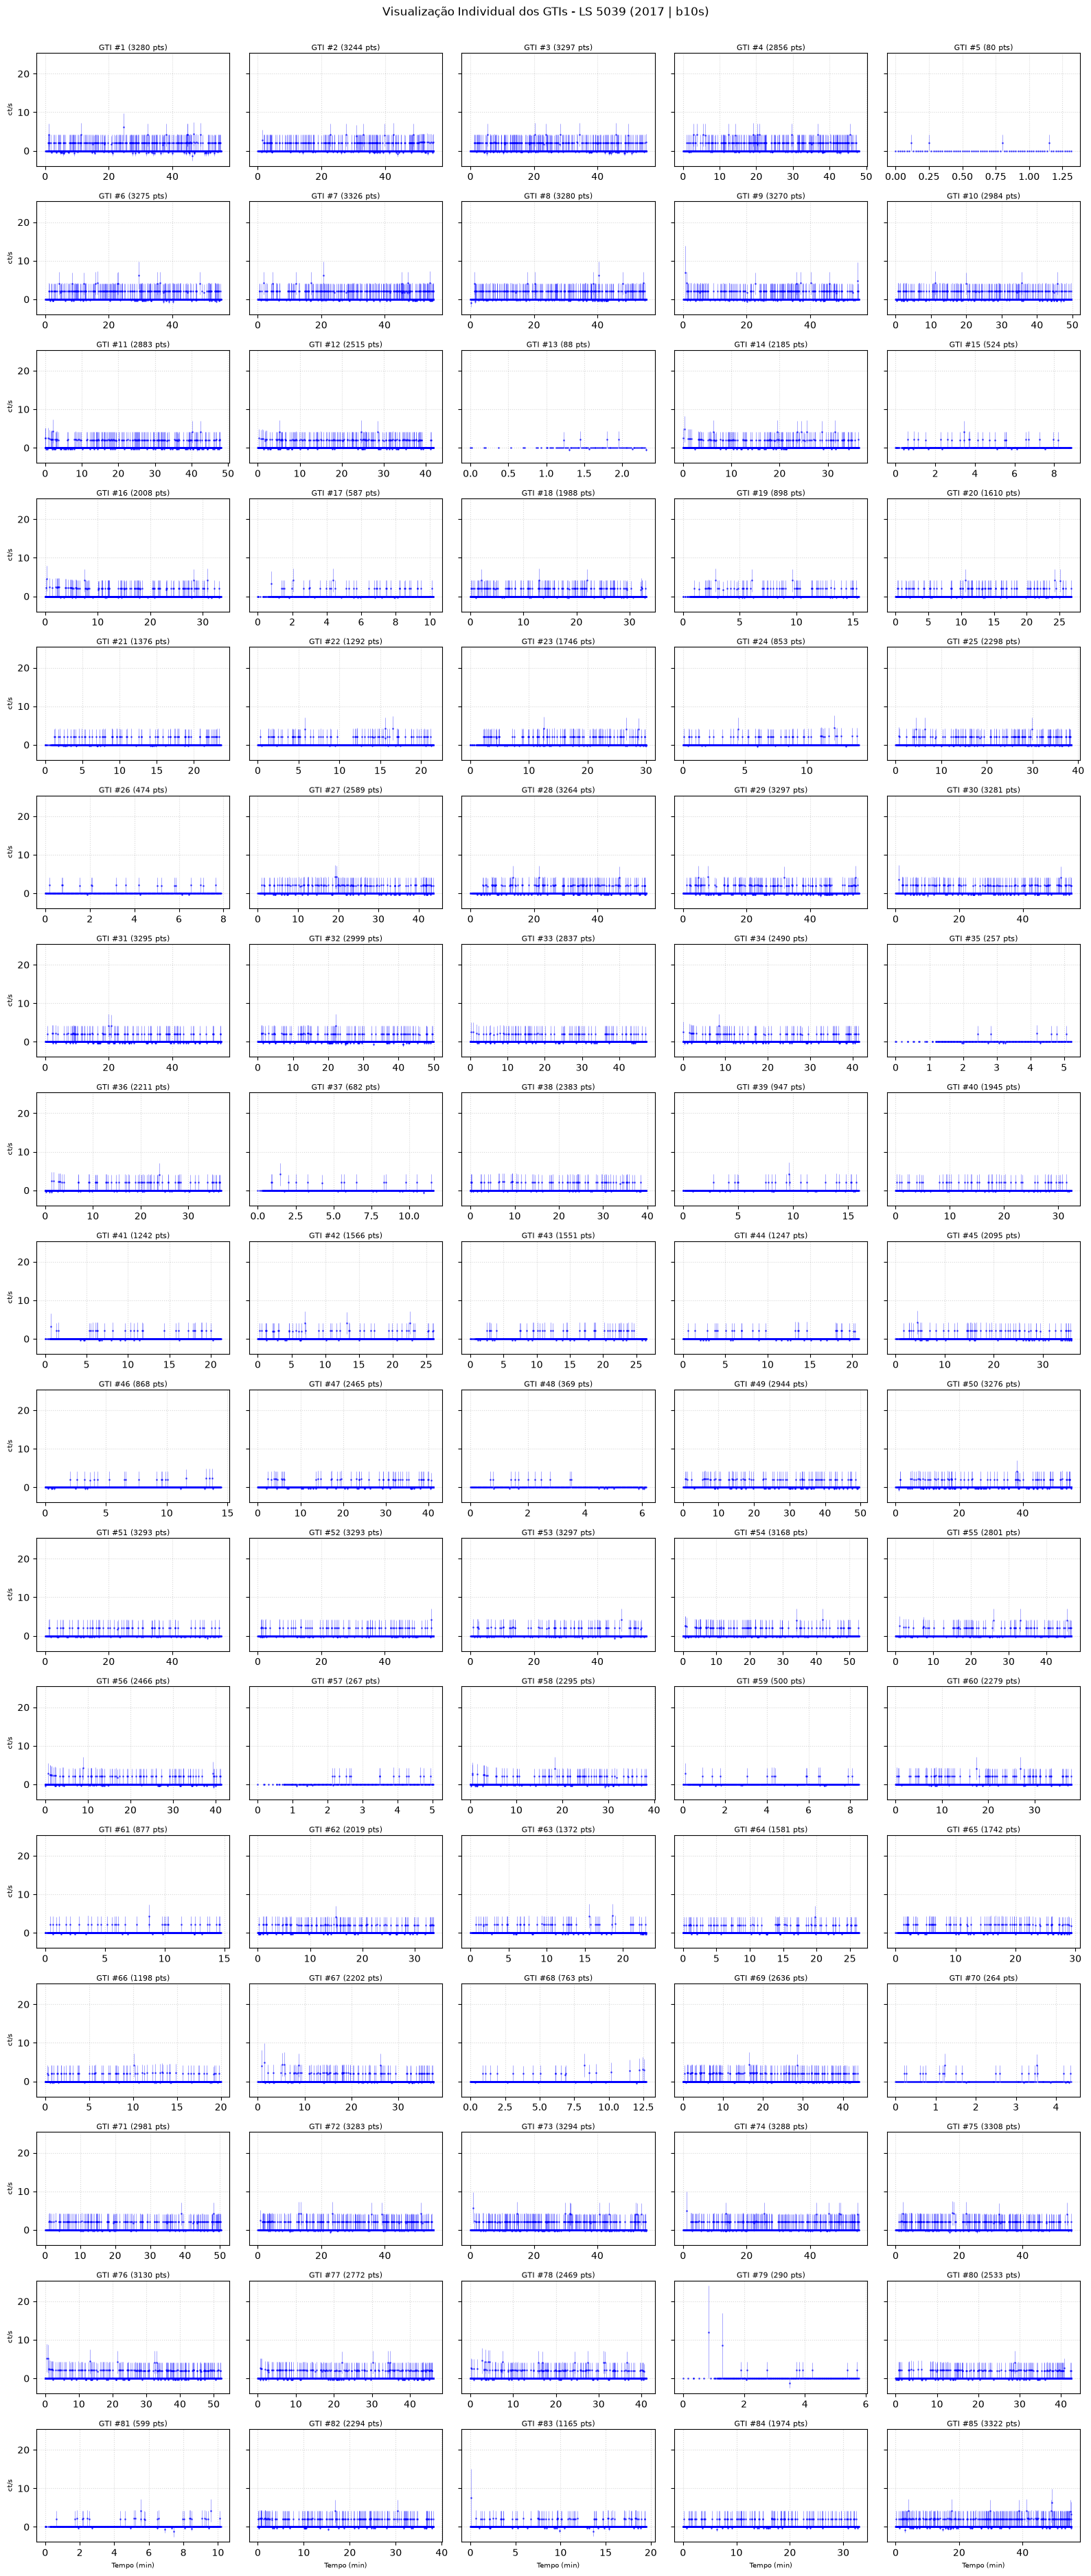

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def extrair_segmentos_gti(time, rate, err=None, limite_gap_seg=30, min_pontos=30):
    """Extrai uma lista com as curvas de luz de cada GTI individual."""
    dt = np.diff(time)
    quebras = np.where(dt > limite_gap_seg)[0]
    
    indices_inicio = np.insert(quebras + 1, 0, 0)
    indices_fim = np.append(quebras, len(time) - 1)
    
    segmentos = []
    for start, end in zip(indices_inicio, indices_fim):
        t_seg = time[start:end + 1]
        r_seg = rate[start:end + 1]
        e_seg = err[start:end + 1] if err is not None else None
        
        if len(t_seg) >= min_pontos:
            segmentos.append((t_seg, r_seg, e_seg))
            
    return segmentos

segmentos = extrair_segmentos_gti(time, rate, err)
n_seg = len(segmentos)

print(f"Total de GTIs extraídos para plotagem: {n_seg}")

ncols = 5
nrows = int(np.ceil(n_seg / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.2), sharey=True)
axes = axes.flatten()

for i, (t_seg, r_seg, e_seg) in enumerate(segmentos):
    ax = axes[i]
    
    t_min = (t_seg - t_seg[0]) / 60.0
    
    if e_seg is not None:
        ax.errorbar(t_min, r_seg, yerr=e_seg, fmt='b.', alpha=0.6, markersize=2, elinewidth=0.4)
    else:
        ax.plot(t_min, r_seg, 'b.', alpha=0.6, markersize=2)
        
    ax.set_title(f'GTI #{i+1} ({len(t_seg)} pts)', fontsize=8, pad=3)
    ax.grid(True, ls=':', alpha=0.5)
    
    if i % ncols == 0:
        ax.set_ylabel('ct/s', fontsize=7)
    if i >= n_seg - ncols:
        ax.set_xlabel('Tempo (min)', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Visualização Individual dos GTIs - LS 5039 ({ano} | {binagem})', fontsize=12, y=1.002)
plt.tight_layout()
plt.show()